# Notebook 06 — Retrieval Alignment: Novel Technique 3

**TIN-7: Cross-Lingual Embedding Alignment Analysis**

CKA measures geometric similarity, but does that similarity
**actually help** with a downstream task? This notebook tests
**functional alignment** via parallel sentence retrieval: given an
English sentence embedding, can we find its translation in another
language by nearest-neighbor search?

## Metrics

- **MRR (Mean Reciprocal Rank)**: Average of 1/rank. MRR=1.0 means
  every translation is the nearest neighbor.
- **Recall@1**: Fraction where the correct translation is the
  single nearest neighbor. The strictest test.
- **Recall@10**: Fraction where the translation is in the top 10.

In [1]:
import logging
import sys
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

PROJECT_ROOT = Path("../..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.languages import Language
from src.analysis.cross_lingual_embedding_alignment.retrieval_metrics import (
    compute_all_retrieval_metrics,
    compute_cosine_similarity_matrix,
)
from src.analysis.cross_lingual_embedding_alignment.visualization import plot_retrieval_curves, plot_recall_bars

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")

RESULTS_DIR = PROJECT_ROOT / "analysis" / "results" / "cross_lingual"
FIGURES_DIR = RESULTS_DIR / "figures"
METRICS_DIR = RESULTS_DIR / "metrics"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load Cached Activations

In [2]:
languages = list(Language)
language_names = [lang.lang_name for lang in languages]
iso_names = [lang.iso_code for lang in languages]
n_layers = 4

activations: dict[str, dict[str, torch.Tensor]] = {}
for lang in languages:
    activations[lang.lang_name] = {}
    for layer_idx in range(n_layers):
        filepath = RESULTS_DIR / "activations" / f"layer_{layer_idx}_{lang.lang_name}.pt"
        if filepath.exists():
            activations[lang.lang_name][f"layer_{layer_idx}"] = torch.load(
                filepath, weights_only=True
            )

print(f"Loaded activations for {len(activations)} languages.")

Loaded activations for 13 languages.


## 2. Compute Retrieval Metrics for All Layers

For each layer and each target language, we compute MRR, Recall@1,
Recall@5, and Recall@10 using English as the source language.

In [3]:
SOURCE_LANG = "english"
K_VALUES = [1, 5, 10]

# Results: {layer_idx: {target_lang: {metric: value}}}
all_retrieval_results: dict[int, dict[str, dict[str, float]]] = {}

for layer_idx in range(n_layers):
    layer_name = f"layer_{layer_idx}"
    layer_results: dict[str, dict[str, float]] = {}

    src_emb = activations[SOURCE_LANG][layer_name].numpy()

    print(f"\n=== Layer {layer_idx} ===")
    for lang in languages:
        if lang.lang_name == SOURCE_LANG:
            continue

        tgt_emb = activations[lang.lang_name][layer_name].numpy()
        metrics = compute_all_retrieval_metrics(src_emb, tgt_emb, k_values=K_VALUES)
        layer_results[lang.lang_name] = metrics

        print(
            f"  {lang.iso_code:<4} MRR={metrics['mrr']:.4f}  "
            f"R@1={metrics['recall@1']:.4f}  "
            f"R@10={metrics['recall@10']:.4f}  "
            f"Median rank={metrics['median_rank']:.0f}"
        )

    all_retrieval_results[layer_idx] = layer_results


=== Layer 0 ===
  hi   MRR=0.0085  R@1=0.0020  R@10=0.0138  Median rank=494
  bn   MRR=0.0082  R@1=0.0020  R@10=0.0109  Median rank=494
  ta   MRR=0.0089  R@1=0.0020  R@10=0.0119  Median rank=484
  sw   MRR=0.0380  R@1=0.0227  R@10=0.0563  Median rank=374
  am   MRR=0.0125  R@1=0.0040  R@10=0.0208  Median rank=470
  yo   MRR=0.0196  R@1=0.0089  R@10=0.0306  Median rank=476
  ar   MRR=0.0512  R@1=0.0237  R@10=0.0958  Median rank=286
  tr   MRR=0.0638  R@1=0.0366  R@10=0.1028  Median rank=316
  fa   MRR=0.0306  R@1=0.0138  R@10=0.0474  Median rank=386
  de   MRR=0.1281  R@1=0.0929  R@10=0.1927  Median rank=225
  fr   MRR=0.1062  R@1=0.0781  R@10=0.1532  Median rank=224
  es   MRR=0.1230  R@1=0.0889  R@10=0.1877  Median rank=188

=== Layer 1 ===
  hi   MRR=0.0083  R@1=0.0010  R@10=0.0128  Median rank=490
  bn   MRR=0.0086  R@1=0.0020  R@10=0.0109  Median rank=488
  ta   MRR=0.0089  R@1=0.0020  R@10=0.0128  Median rank=479
  sw   MRR=0.0646  R@1=0.0415  R@10=0.1038  Median rank=315
  am  

## 3. MRR vs. Layer Depth (Per Target Language)

INFO: Figure saved to /teamspace/studios/this_studio/Tiny-Aya-Under-the-hood/analysis/results/cross_lingual/figures/retrieval_mrr_curve.png


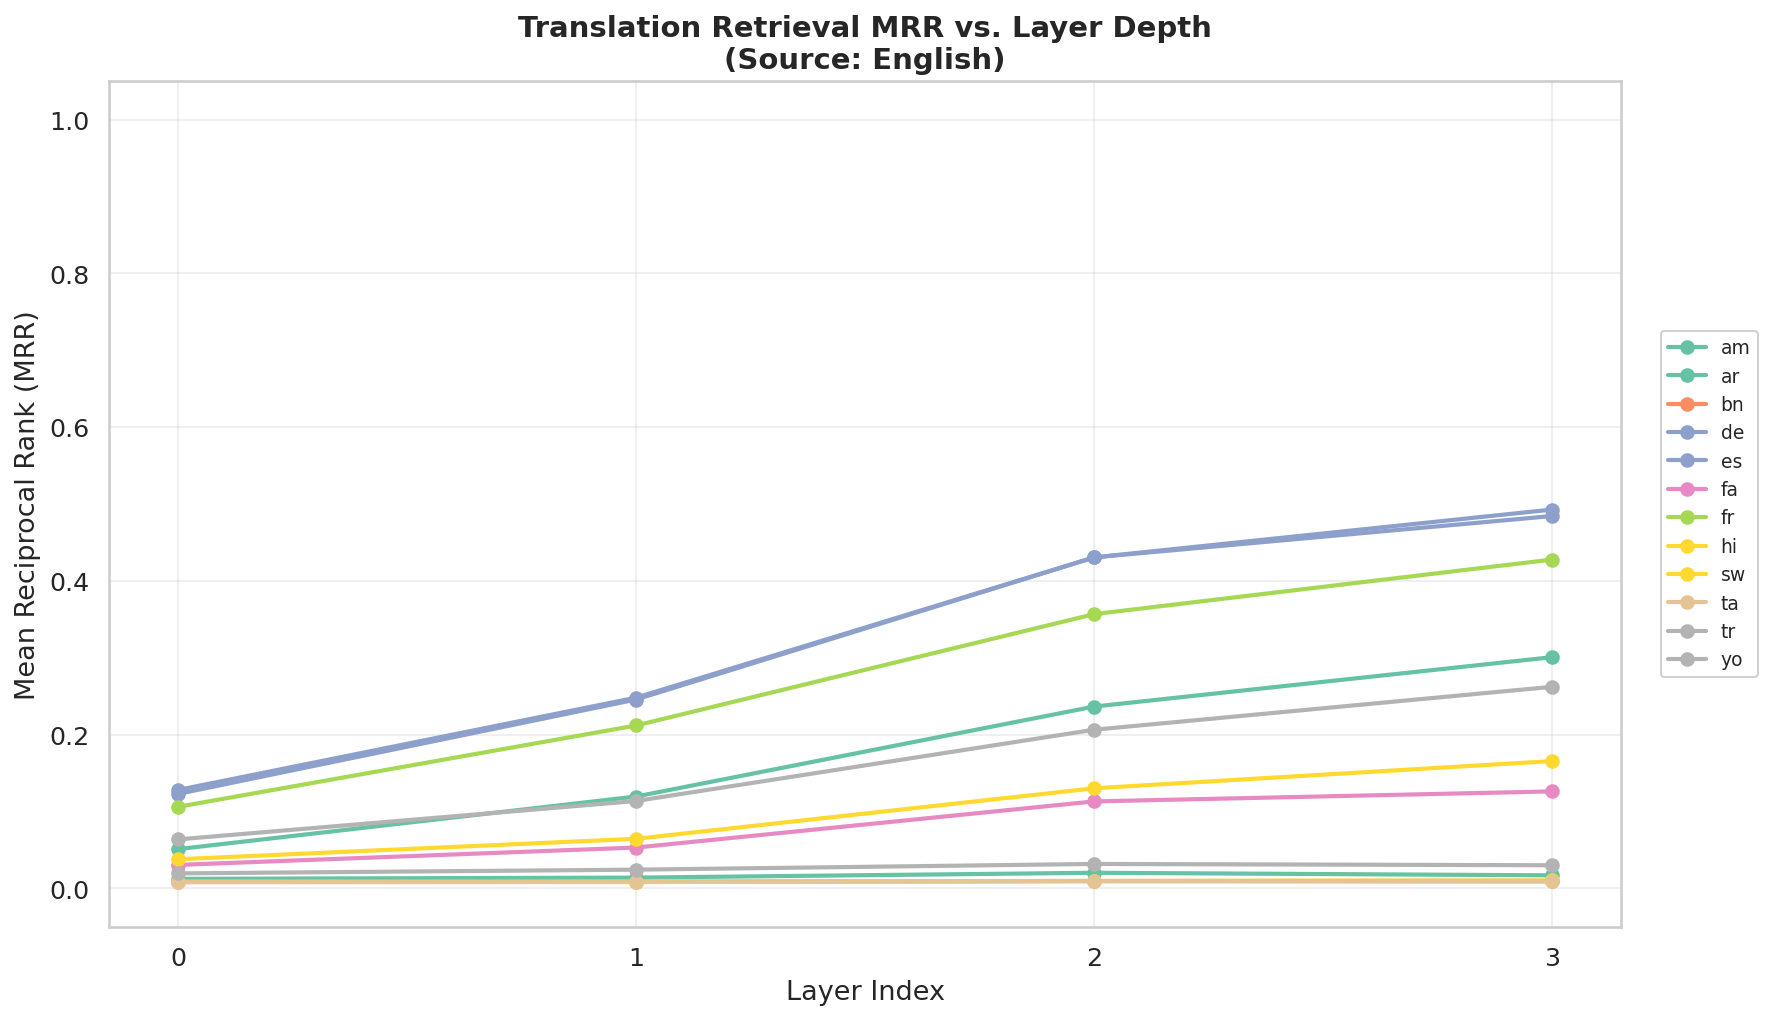

In [4]:
# Prepare data for plotting.
mrr_per_lang: dict[str, list[float]] = {}
for lang in languages:
    if lang.lang_name == SOURCE_LANG:
        continue
    mrr_values = []
    for layer_idx in range(n_layers):
        mrr_values.append(all_retrieval_results[layer_idx][lang.lang_name]["mrr"])
    mrr_per_lang[lang.iso_code] = mrr_values

fig = plot_retrieval_curves(
    layer_indices=list(range(n_layers)),
    mrr_per_layer=mrr_per_lang,
    title="Translation Retrieval MRR vs. Layer Depth\n(Source: English)",
    save_path=str(FIGURES_DIR / "retrieval_mrr_curve.png"),
)
plt.show()

## 4. Recall@1 and Recall@10 at Best Layer

Show per-language retrieval accuracy at the layer with the highest
average MRR.

Best layer for retrieval: Layer 3 (avg MRR = 0.1948)


INFO: Figure saved to /teamspace/studios/this_studio/Tiny-Aya-Under-the-hood/analysis/results/cross_lingual/figures/recall_at_1_layer_3.png


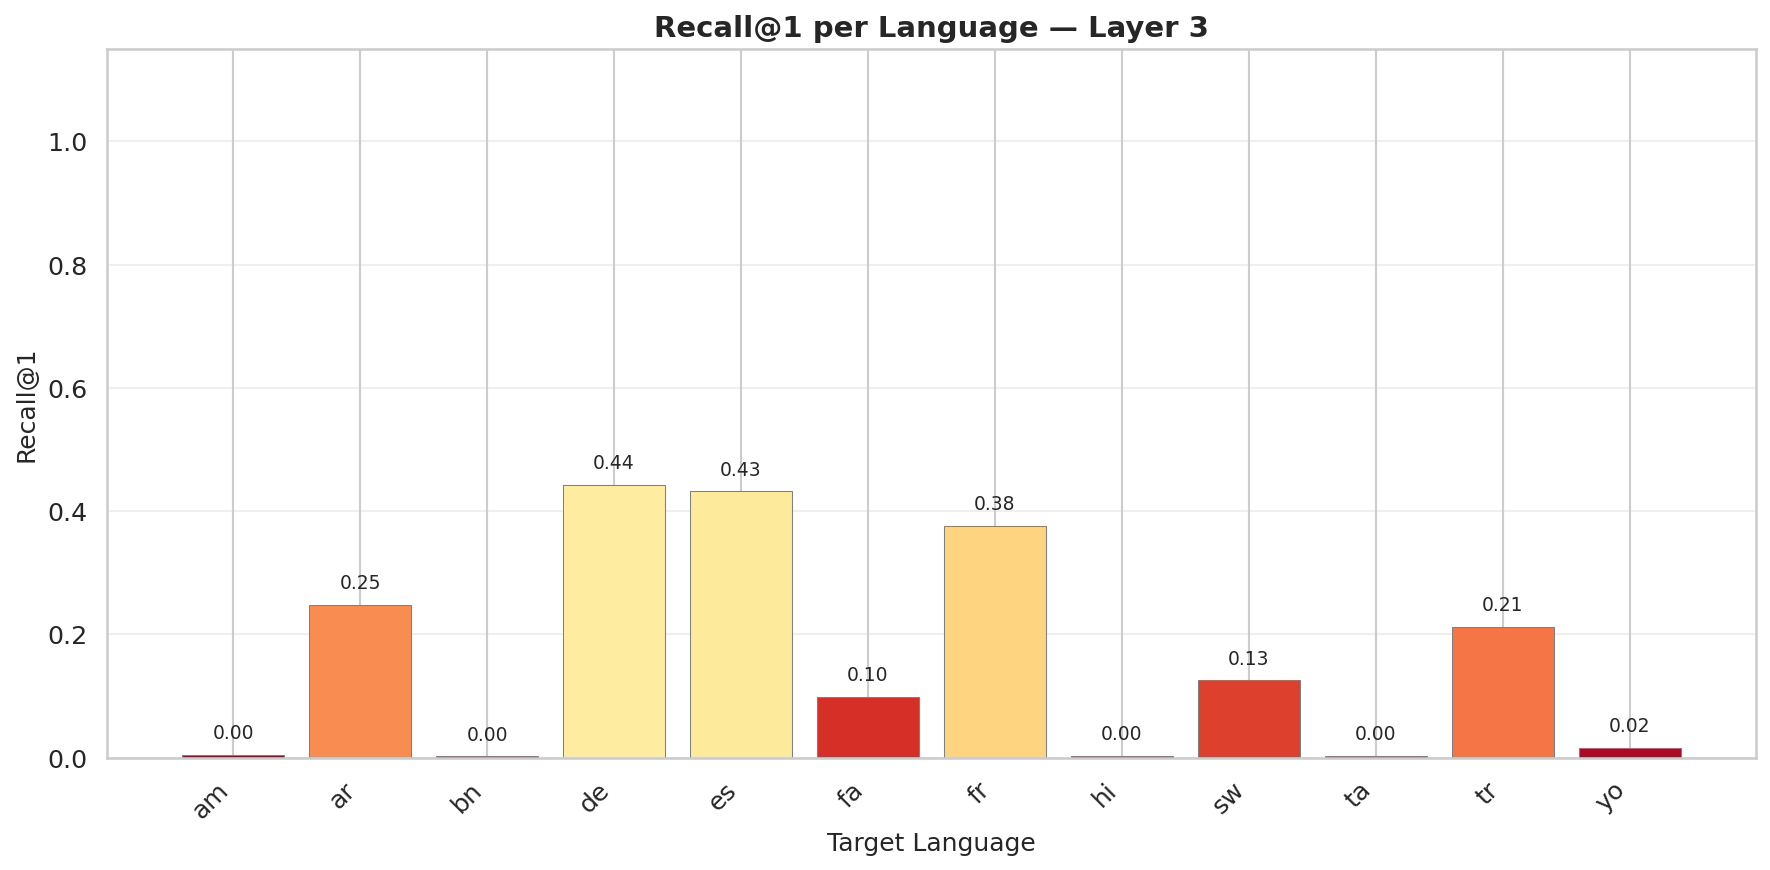

INFO: Figure saved to /teamspace/studios/this_studio/Tiny-Aya-Under-the-hood/analysis/results/cross_lingual/figures/recall_at_10_layer_3.png


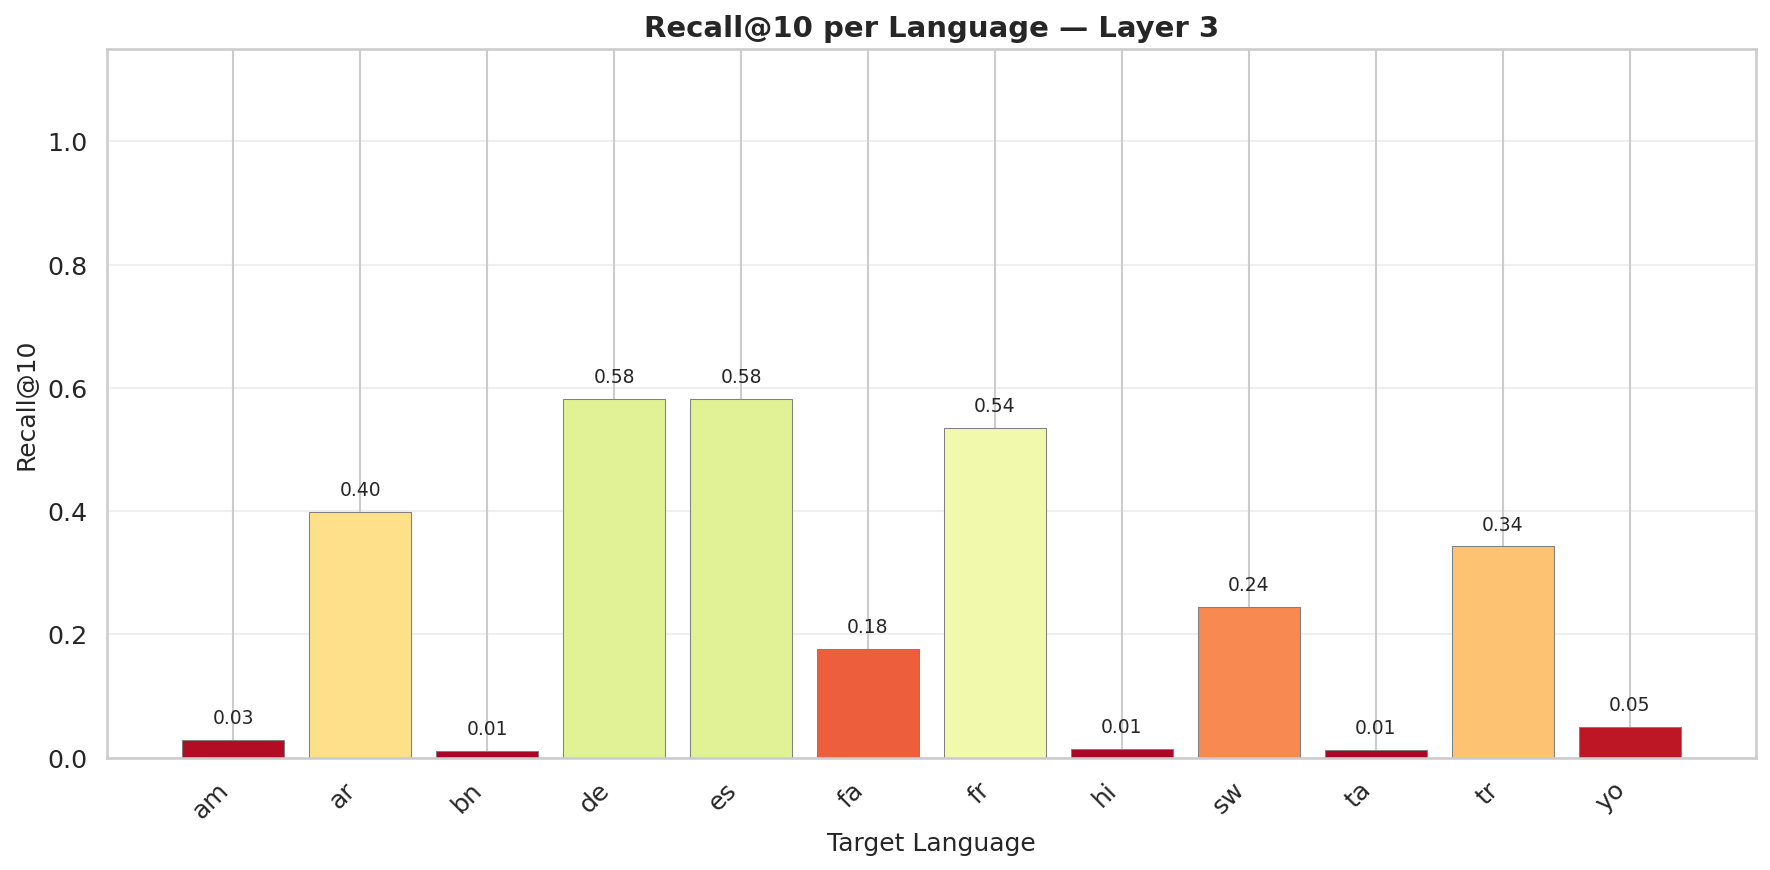

In [5]:
# Find the best layer (highest average MRR).
avg_mrr_per_layer = []
for layer_idx in range(n_layers):
    mrr_values = [
        all_retrieval_results[layer_idx][lang.lang_name]["mrr"]
        for lang in languages if lang.lang_name != SOURCE_LANG
    ]
    avg_mrr_per_layer.append(np.mean(mrr_values))

best_layer = int(np.argmax(avg_mrr_per_layer))
print(f"Best layer for retrieval: Layer {best_layer} (avg MRR = {avg_mrr_per_layer[best_layer]:.4f})")

# Recall@1 bar chart.
recall_at_1: dict[str, float] = {
    lang.iso_code: all_retrieval_results[best_layer][lang.lang_name]["recall@1"]
    for lang in languages if lang.lang_name != SOURCE_LANG
}

fig = plot_recall_bars(
    recall_scores=recall_at_1,
    k=1,
    layer_index=best_layer,
    save_path=str(FIGURES_DIR / f"recall_at_1_layer_{best_layer}.png"),
)
plt.show()

# Recall@10 bar chart.
recall_at_10: dict[str, float] = {
    lang.iso_code: all_retrieval_results[best_layer][lang.lang_name]["recall@10"]
    for lang in languages if lang.lang_name != SOURCE_LANG
}

fig = plot_recall_bars(
    recall_scores=recall_at_10,
    k=10,
    layer_index=best_layer,
    save_path=str(FIGURES_DIR / f"recall_at_10_layer_{best_layer}.png"),
)
plt.show()

## 5. Retrieval Error Analysis

For the best layer, show the hardest-to-retrieve sentence pairs —
cases where the correct translation is ranked furthest from the top.


=== Hardest Retrievals: English -> arabic (Layer 3) ===
  Rank  Sent#
------------------------------
  1002   #296
   996   #482
   988   #854
   979   #841
   943   #366
   933   #205
   931   #192
   930   #398
   920   #558
   919   #850


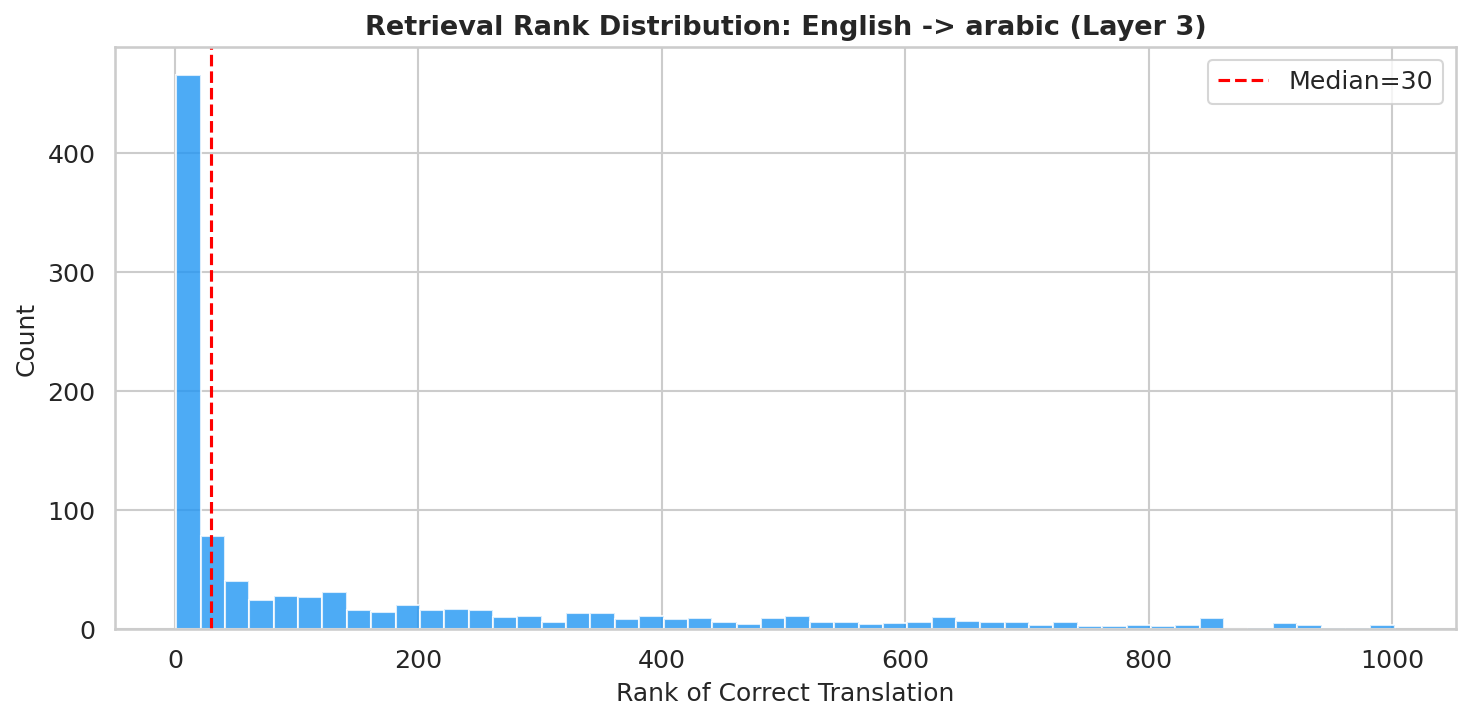

In [6]:
# Analyze retrieval errors for one target language.
ERROR_ANALYSIS_LANG = "arabic"
ERROR_ANALYSIS_LAYER = best_layer
layer_name = f"layer_{ERROR_ANALYSIS_LAYER}"

src_emb = activations[SOURCE_LANG][layer_name].numpy()
tgt_emb = activations[ERROR_ANALYSIS_LANG][layer_name].numpy()

# Compute full similarity matrix.
sim_matrix = compute_cosine_similarity_matrix(src_emb, tgt_emb)

# Find ranks of correct translations.
n_sentences = src_emb.shape[0]
ranks = np.zeros(n_sentences, dtype=np.int64)
for i in range(n_sentences):
    ranked = np.argsort(-sim_matrix[i])
    ranks[i] = np.where(ranked == i)[0][0] + 1

# Show worst-ranked translations (hardest to retrieve).
worst_indices = np.argsort(-ranks)[:10]

print(f"\n=== Hardest Retrievals: English -> {ERROR_ANALYSIS_LANG} (Layer {ERROR_ANALYSIS_LAYER}) ===")
print(f"{'Rank':>6} {'Sent#':>6}")
print("-" * 30)
for idx in worst_indices:
    print(f"  {ranks[idx]:>4}   #{idx}")

# Rank distribution histogram.
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(ranks, bins=50, color="#2196F3", edgecolor="white", alpha=0.8)
ax.set_xlabel("Rank of Correct Translation", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title(
    f"Retrieval Rank Distribution: English -> {ERROR_ANALYSIS_LANG} (Layer {ERROR_ANALYSIS_LAYER})",
    fontsize=13, fontweight="bold",
)
ax.axvline(x=np.median(ranks), color="red", linestyle="--", label=f"Median={np.median(ranks):.0f}")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES_DIR / f"retrieval_rank_dist_{ERROR_ANALYSIS_LANG}.png", bbox_inches="tight")
plt.show()

## 6. Save Metrics

In [7]:
retrieval_metrics: dict[str, float] = {}
for layer_idx in range(n_layers):
    for lang in languages:
        if lang.lang_name == SOURCE_LANG:
            continue
        metrics = all_retrieval_results[layer_idx][lang.lang_name]
        prefix = f"layer_{layer_idx}_en_{lang.iso_code}"
        retrieval_metrics[f"{prefix}_mrr"] = metrics["mrr"]
        retrieval_metrics[f"{prefix}_recall_at_1"] = metrics["recall@1"]
        retrieval_metrics[f"{prefix}_recall_at_10"] = metrics["recall@10"]

with open(METRICS_DIR / "retrieval_scores.json", "w") as f:
    json.dump(retrieval_metrics, f, indent=2)

print(f"Retrieval metrics saved to {METRICS_DIR / 'retrieval_scores.json'}")

Retrieval metrics saved to /teamspace/studios/this_studio/Tiny-Aya-Under-the-hood/analysis/results/cross_lingual/metrics/retrieval_scores.json


## 7. Summary

**Retrieval metrics per target language (source = English) across all 4 layers:**

| Lang | L0 MRR | L0 R@1  | L0 R@10 | L3 MRR | L3 R@1  | L3 R@10 | L3 Med. Rank |
|------|--------|---------|---------|--------|---------|---------|-------------|
| hi   | 0.0085 | 0.0020  | 0.0138  | 0.0105 | 0.0030  | 0.0138  | 466         |
| bn   | 0.0082 | 0.0020  | 0.0109  | 0.0091 | 0.0020  | 0.0109  | 473         |
| ta   | 0.0089 | 0.0020  | 0.0119  | 0.0099 | 0.0030  | 0.0128  | 457         |
| sw   | 0.0380 | 0.0227  | 0.0563  | 0.1657 | 0.1255  | 0.2441  | 141         |
| am   | 0.0125 | 0.0040  | 0.0208  | 0.0171 | 0.0049  | 0.0287  | 404         |
| yo   | 0.0196 | 0.0089  | 0.0306  | 0.0302 | 0.0158  | 0.0504  | 440         |
| ar   | 0.0512 | 0.0237  | 0.0958  | 0.3009 | 0.2480  | 0.3992  | 30          |
| tr   | 0.0638 | 0.0366  | 0.1028  | 0.2623 | 0.2125  | 0.3429  | 60          |
| fa   | 0.0306 | 0.0138  | 0.0474  | 0.1262 | 0.0988  | 0.1769  | 198         |
| de   | 0.1281 | 0.0929  | 0.1927  | 0.4929 | 0.4427  | 0.5820  | 3           |
| fr   | 0.1062 | 0.0781  | 0.1532  | 0.4278 | 0.3755  | 0.5356  | 7           |
| es   | 0.1230 | 0.0889  | 0.1877  | 0.4845 | 0.4318  | 0.5820  | 3           |

**Key findings:**
- **Best layer for translation retrieval is Layer 3** (the deepest layer), with an average MRR
  of 0.1948 across all target languages. Retrieval quality improves monotonically with depth
  at every layer for nearly every language.
- **MRR varies enormously across target languages** — from 0.0082 (Bengali, Layer 0)
  to 0.4929 (German, Layer 3). At Layer 3, MRR spans a 54× gap between Bengali (0.0091)
  and German (0.4929).
- **High-resource, Latin-script languages dominate retrieval performance.** German
  (MRR=0.4929), Spanish (0.4845), and French (0.4278) are the top three at Layer 3, with
  Recall@1 of 44.3%, 43.2%, and 37.6% respectively. These are the languages most similar to
  English in script and training data availability.
- **Non-Latin-script, lower-resource languages perform poorly.** Hindi (MRR=0.0105),
  Bengali (0.0091), and Tamil (0.0099) have near-chance MRR even at Layer 3, with median
  retrieval ranks of 466, 473, and 457 (out of ~1012). Amharic (0.0171, rank 404) and
  Yoruba (0.0302, rank 440) are also very low.
- **A clear middle tier exists** for languages that share some typological or script proximity
  with English: Arabic (MRR=0.3009, rank 30), Turkish (0.2623, rank 60), Swahili (0.1657,
  rank 141), and Persian (0.1262, rank 198) all show substantial improvement with depth
  but remain well below the Latin-script group.
- **Functional alignment only partially tracks geometric alignment.** While Notebooks 03 and 05
  showed uniformly high CKA (especially after whitening), retrieval performance reveals that
  high geometric similarity does not guarantee good functional (task-level) alignment.
  The representations may occupy similar subspaces in aggregate, but sentence-level
  correspondences are weak for many language pairs — particularly those involving different
  scripts and lower-resource languages.